In [1]:
import tensorflow as tf
import os
import numpy as np
import keras
from keras import layers
from tensorflow import data as tf_data
import matplotlib.pyplot as plt

data_dir = "MushroomPics"
dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(244, 244),
    batch_size=8,
    shuffle=True
)
#dataset = dataset.apply(tf.data.experimental.ignore_errors())

length = len(dataset)

train_size = int(length * 0.7)
test_size = int(length * 0.15)

train = dataset.take(train_size)
test = dataset.skip(train_size).take(test_size)
val = dataset.skip(train_size + test_size)

print(dataset.class_names)
print(dataset)

C:\Users\leevi\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Found 6714 files belonging to 9 classes.
['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))>


In [2]:
model = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    
    #layers.Flatten(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(len(dataset.class_names))
])

C:\Users\leevi\anaconda3\envs\keras\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [4]:
history = model.fit(
    train,
    validation_data=val,
    epochs=64
)

Epoch 1/64
588/588 ━━━━━━━━━━━━━━━━━━━━ 113s 188ms/step - accuracy: 0.2109 - loss: 2.0686 - val_accuracy: 0.2545 - val_loss: 2.0323
Epoch 2/64
588/588 ━━━━━━━━━━━━━━━━━━━━ 111s 189ms/step - accuracy: 0.2268 - loss: 2.0445 - val_accuracy: 0.2585 - val_loss: 2.0119
Epoch 3/64
588/588 ━━━━━━━━━━━━━━━━━━━━ 111s 189ms/step - accuracy: 0.2321 - loss: 2.0174 - val_accuracy: 0.2625 - val_loss: 1.9646
Epoch 4/64
588/588 ━━━━━━━━━━━━━━━━━━━━ 112s 191ms/step - accuracy: 0.2394 - loss: 1.9735 - val_accuracy: 0.2645 - val_loss: 1.9303
Epoch 5/64
588/588 ━━━━━━━━━━━━━━━━━━━━ 111s 189ms/step - accuracy: 0.2462 - loss: 1.9374 - val_accuracy: 0.2894 - val_loss: 1.8972
Epoch 6/64
588/588 ━━━━━━━━━━━━━━━━━━━━ 111s 189ms/step - accuracy: 0.2591 - loss: 1.9140 - val_accuracy: 0.3144 - val_loss: 1.8532
Epoch 7/64
588/588 ━━━━━━━━━━━━━━━━━━━━ 111s 188ms/step - accuracy: 0.2840 - loss: 1.8705 - val_accuracy: 0.3184 - val_loss: 1.8270
Epoch 8/64
588/588 ━━━━━━━━━━━━━━━━━━━━ 110s 188ms/step - accuracy: 0.3089 -

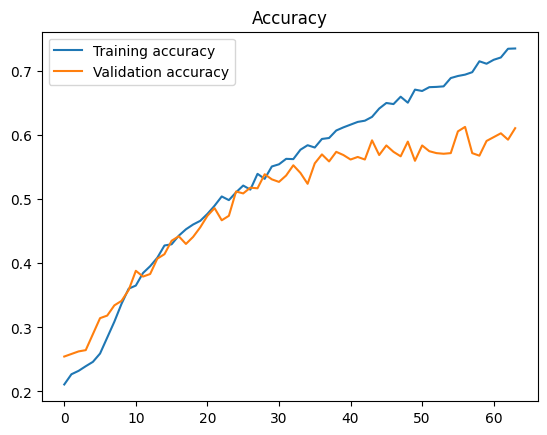

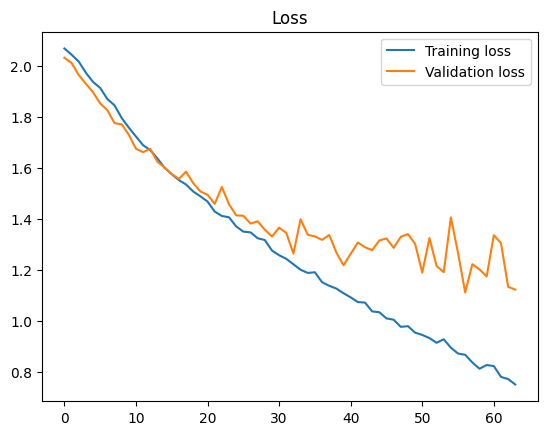

In [5]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.legend()
plt.title('Loss')
plt.show()

In [6]:
import tensorflow as tf

for root, _, files in os.walk("Mushrooms"):
    for f in files:
        path = os.path.join(root, f)
        try:
            img = tf.io.read_file(path)
            tf.io.decode_image(img)
        except Exception as e:
            print("BAD FILE:", path)

In [7]:
test_loss, test_acc = model.evaluate(test)
val_loss, val_acc = model.evaluate(val)
print("Test accuracy:", test_acc)
print("Validation accuracy:", val_acc)

126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.6538 - loss: 1.1916
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.6148 - loss: 1.1149
Test accuracy: 0.653769850730896
Validation accuracy: 0.6147704720497131
